<h1 style = "color: #000080;"><strong><em><center>The Association Between Hours Of Sleep & Mode Of Transportation On Teenagers</strong></em></center></h1>

<h2 style = "color: #000080;"><strong><center>Statistical Investigation Question:</strong></center></h2>

<h3 style = "color: #000080;"><center>How do recommended and sufficient hours of sleep associate with the mode of transportation teenagers take to school?</center>

<h2 style = "color: #000080;"><strong><center>Type of Statistical Study:</strong></center></h2>

<h3 style = "color: #000080;"><center>I plan to conduct an observational study to answer my statistical question because the data was accumulated by observing the students' sleep habits and transportation choices without incorporating any treatments or controlling their behavior. Additionally, I only have access to a sample of data collected from the American Statistical Association. This sample is not representative of the student population of the United States.</center>

In [32]:
from IPython.display import HTML, display

display(
    HTML("""
<style>
    /* Main background color */
    .jp-Notebook, .container, #notebook-container {
        background-color: skyblue !important;
    }
    
    /* Optional: match cell backgrounds */
    .jp-Cell, .cell {
        background-color: skyblue !important;
    }
</style>
""")
)

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# Travel_to_School
# Sleep_Hours_Schoolnight
df = pd.read_csv("CensusAtSchool.csv")

<h3 style = "color: #000080;"><center>Study Type: Observational Study (measuring naturally occurring habits without imposing treatments).</center>
<h3 style = "color: #000080;"><center>Veriables To Be Examined: Travel_to_School (categorical) & Sleep_Hours_Schoolnight (categorical/binned). </center>

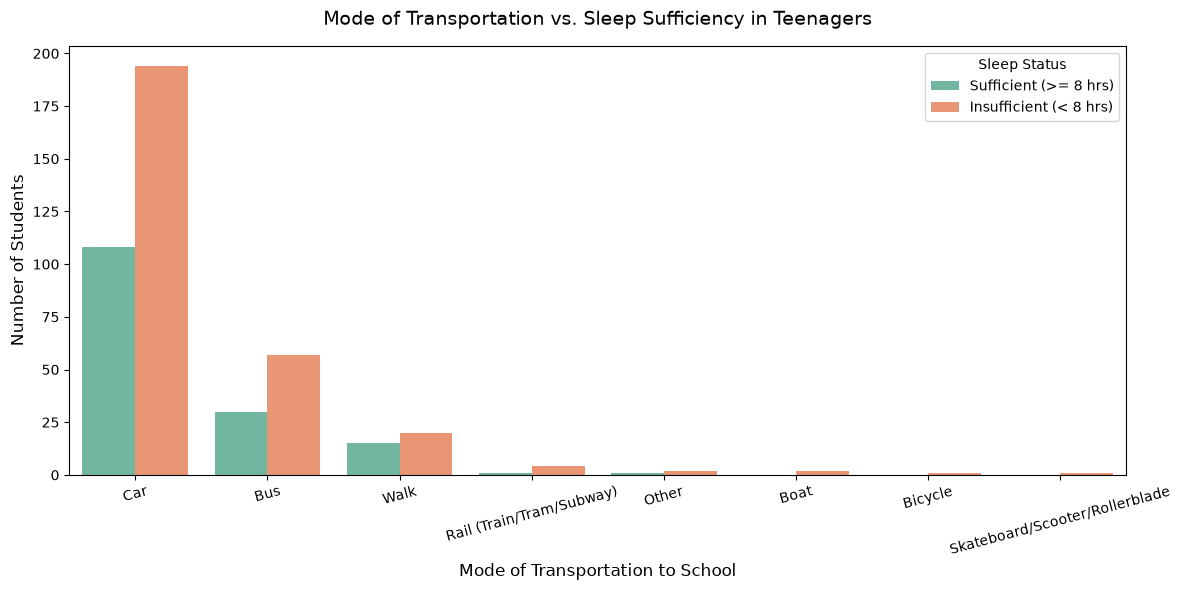

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv("CensusAtSchool.csv")

# 2. Clean sleep hours and define sufficiency (8+ hours is standard for teens)
df["Sleep_Hours_Schoolnight"] = pd.to_numeric(
    df["Sleep_Hours_Schoolnight"], errors="coerce"
)
df["Sufficient_Sleep"] = df["Sleep_Hours_Schoolnight"].apply(
    lambda x: "Sufficient (>= 8 hrs)"
    if x >= 8
    else ("Insufficient (< 8 hrs)" if x < 8 else None)
)

# 3. Filter out missing values for clean visualization
clean_df = df.dropna(subset=["Sufficient_Sleep", "Travel_to_School"])

# 4. Create side-by-side bar chart
plt.figure(figsize=(12, 6))
sns.countplot(
    data=clean_df,
    x="Travel_to_School",
    hue="Sufficient_Sleep",
    palette="Set2",
    order=clean_df["Travel_to_School"].value_counts().index,  # Sort by frequency
)

# 5. Add titles and formatting
plt.title(
    "Mode of Transportation vs. Sleep Sufficiency in Teenagers",
    fontsize=14,
    pad=15,
)
plt.xlabel("Mode of Transportation to School", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.legend(title="Sleep Status")
plt.xticks(rotation=15)
plt.tight_layout()

# 6. Display chart in notebook
plt.show()

In [36]:
# 1. Clean & define variables
df["Sleep_Hours_Schoolnight"] = pd.to_numeric(
    df["Sleep_Hours_Schoolnight"], errors="coerce"
)
df["Sufficient_Sleep"] = df["Sleep_Hours_Schoolnight"].apply(
    lambda x: "Sufficient (>= 8 hrs)"
    if x >= 8
    else ("Insufficient (< 8 hrs)" if x < 8 else None)
)
clean_df = df.dropna(subset=["Sufficient_Sleep", "Travel_to_School"])


# Centering helper function using raw HTML wrapper
def display_centered(df):
    html_table = df.style.set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ]
    ).to_html()

    centered_html = f"""
    <div style="display: flex; justify-content: center; width: 100%;">
        {html_table}
    </div>
    """
    display(HTML(centered_html))


# ---------------------------------------------------------
# 1. RAW COUNTS TABLE
# ---------------------------------------------------------
ct_counts = pd.crosstab(
    clean_df["Travel_to_School"],
    clean_df["Sufficient_Sleep"],
    margins=True,
    margins_name="Total",
)

print("=" * 60)
print("1. RAW COUNTS TABLE".center(60))
print("=" * 60)
display_centered(ct_counts)


# ---------------------------------------------------------
# 2. JOINT & MARGINAL RELATIVE FREQUENCIES (%)
# ---------------------------------------------------------
ct_joint_marginal = (
    pd.crosstab(
        clean_df["Travel_to_School"],
        clean_df["Sufficient_Sleep"],
        margins=True,
        margins_name="Total",
        normalize=True,
    )
    * 100
)

print("\n" + "=" * 60)
print("2. JOINT & MARGINAL RELATIVE FREQUENCIES (%)".center(60))
print("=" * 60)
display_centered(ct_joint_marginal.round(2))


# ---------------------------------------------------------
# 3. CONDITIONAL RELATIVE FREQUENCIES (%)
# ---------------------------------------------------------
ct_conditional = (
    pd.crosstab(
        clean_df["Travel_to_School"],
        clean_df["Sufficient_Sleep"],
        normalize="index",
    )
    * 100
)

print("\n" + "=" * 60)
print("3. CONDITIONAL RELATIVE FREQUENCIES BY TRAVEL MODE (%)".center(60))
print("=" * 60)
display_centered(ct_conditional.round(2))

                    1. RAW COUNTS TABLE                     


Sufficient_Sleep,Insufficient (< 8 hrs),Sufficient (>= 8 hrs),Total
Travel_to_School,,,
Bicycle,1,0,1
Boat,2,0,2
Bus,57,30,87
Car,194,108,302
Other,2,1,3
Rail (Train/Tram/Subway),4,1,5
Skateboard/Scooter/Rollerblade,1,0,1
Walk,20,15,35
Total,281,155,436



        2. JOINT & MARGINAL RELATIVE FREQUENCIES (%)        


Sufficient_Sleep,Insufficient (< 8 hrs),Sufficient (>= 8 hrs),Total
Travel_to_School,,,
Bicycle,0.230000,0.000000,0.230000
Boat,0.460000,0.000000,0.460000
Bus,13.070000,6.880000,19.950000
Car,44.500000,24.770000,69.270000
Other,0.460000,0.230000,0.690000
Rail (Train/Tram/Subway),0.920000,0.230000,1.150000
Skateboard/Scooter/Rollerblade,0.230000,0.000000,0.230000
Walk,4.590000,3.440000,8.030000
Total,64.450000,35.550000,100.000000



   3. CONDITIONAL RELATIVE FREQUENCIES BY TRAVEL MODE (%)   


Sufficient_Sleep,Insufficient (< 8 hrs),Sufficient (>= 8 hrs)
Travel_to_School,,
Bicycle,100.000000,0.000000
Boat,100.000000,0.000000
Bus,65.520000,34.480000
Car,64.240000,35.760000
Other,66.670000,33.330000
Rail (Train/Tram/Subway),80.000000,20.000000
Skateboard/Scooter/Rollerblade,100.000000,0.000000
Walk,57.140000,42.860000


<h2 style = "color: #000080;"><strong><center>Analysis of Data:</strong></center></h2>

<h3 style = "color: #000080;"><center>The grouped bar chart displayed above shows that a significant number of students take a car to school despite sleeping less than eight hours. To be exact, 194 or 64.24% of students ride in cars despite sleeping fewer than eight hours. There are fewer students that use car to school that actually get eight hours or more). Exactly 108 or 35.76% of students ride in cars and sleep for at least eight hours consistently. The bar chart shows that more students, no matter what form of transport they take, don't sleep enough and ride their respective form of transportation to school. For example, the number of students that ride a bus to school after sleeping insufficiently is higher compared than those that take a bus AND sleep for at least eight hours. Note that for almost ALL forms of transportation portrayed on the graph, the orange bar is higher than the turquoise bar.</center>


<h2 style = "color: #000080;"><strong><center>Conclusion:</strong></center></h2>

<h3 style = "color: #000080;"><center>Students that take any form of transportation to school are more likely to fail sleeping for at least eight hours than for at least eight hours. Therefore, the variables "Sufficient_Sleep" and "Travel_to_School" are associated. If they weren't, then the orange and turquoise bars would've looked identical. All in all, more students that commute to school with their mode of transport don't sleep enough.</center>
